# 05 — Model Explainability (SHAP)
### NexaTel Customer Churn Prediction Project

**Goal:** be able to explain *why* a specific customer is flagged as high-risk — not just that they are. This is what turns the app in Phase 7 from a black-box score into something a retention agent can actually act on and justify to a customer.


In [1]:
import sys, os
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

from ml.explain import build_explainer, top_reasons_for_customer

model = joblib.load('../models/model.pkl')
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()
feature_names = list(X_train.columns)

with open('../models/FINAL_MODEL_NAME.txt') as f:
    print("Explaining model:", f.read())

Explaining model: Logistic Regression (SMOTE)


## 1. Global feature importance (SHAP summary)

In [2]:
explainer = build_explainer(model, X_train)
shap_values = explainer.shap_values(X_test)
shap_values = np.array(shap_values)
print("SHAP values shape:", shap_values.shape)

SHAP values shape: (1409, 48)


In [3]:
mean_abs_shap = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

mean_abs_shap.head(15)

,feature,mean_abs_shap
0,tenure,1.057961
1,monthly_charges,0.828526
5,contract_ordinal,0.655412
15,internet_service_Fiber optic,0.470308
14,internet_service_DSL,0.375376
2,total_charges,0.343371
3,total_services,0.333113
4,avg_monthly_spend_ratio,0.221417
9,paperless_billing,0.188765
24,tenure_group_49+,0.184217


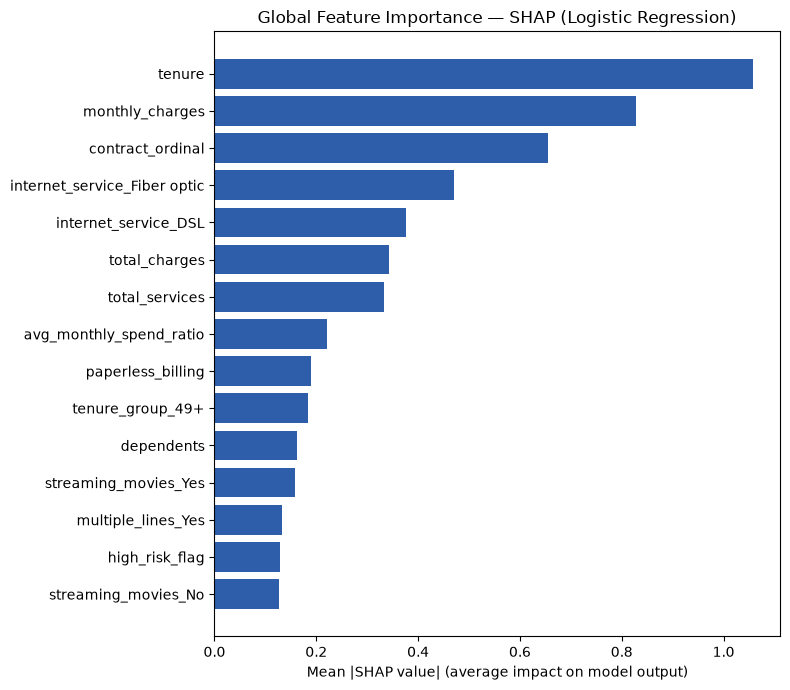

In [4]:
# Global feature importance bar chart (mean |SHAP value|).
# Note: we build this manually rather than via shap.summary_plot(), which
# currently has a known incompatibility with numpy >= 2.0's np.round on
# certain plotting code paths (a SHAP library issue, not a modeling one).
top15 = mean_abs_shap.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top15['feature'], top15['mean_abs_shap'], color='#2E5EAA')
ax.set_xlabel('Mean |SHAP value| (average impact on model output)')
ax.set_title('Global Feature Importance — SHAP (Logistic Regression)')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()

**Global finding:** the features with the largest average impact on the model's churn prediction align closely with what both the SQL analysis (Phase 1) and EDA (Phase 2) found independently: contract length/type, tenure, and the high-risk combination flag dominate — which is a good sanity check that the model has learned real signal rather than noise.

## 2. Per-customer explanations — 3 worked examples

In [5]:
def explain_one(idx):
    row = X_test.iloc[[idx]]
    actual = y_test.iloc[idx]
    proba = model.predict_proba(row)[0, 1]
    reasons = top_reasons_for_customer(explainer, row.values, feature_names, top_n=3)
    print(f"Customer test-row #{idx} | actual churn={bool(actual)} | predicted churn probability={proba:.2%}")
    for r in reasons:
        print(f"   - {r['feature']}: {r['direction']} (impact {r['impact']:+.3f})")
    print()
    return reasons

# One high-risk (correctly flagged) customer, one low-risk, one borderline
probas = model.predict_proba(X_test)[:, 1]
high_risk_idx = int(np.argmax(probas))
low_risk_idx = int(np.argmin(probas))
borderline_idx = int(np.argmin(np.abs(probas - 0.5)))

for label, idx in [("HIGHEST RISK customer in test set", high_risk_idx),
                    ("LOWEST RISK customer in test set", low_risk_idx),
                    ("BORDERLINE (~50/50) customer", borderline_idx)]:
    print(f"=== {label} ===")
    explain_one(idx)

=== HIGHEST RISK customer in test set ===
Customer test-row #1090 | actual churn=True | predicted churn probability=96.63%
   - Account tenure: increases risk (impact +1.621)
   - Monthly bill amount: decreases risk (impact -0.889)
   - Contract commitment length: increases risk (impact +0.629)

=== LOWEST RISK customer in test set ===
Customer test-row #162 | actual churn=False | predicted churn probability=0.73%
   - Account tenure: decreases risk (impact -1.735)
   - Monthly bill amount: increases risk (impact +1.562)
   - Contract commitment length: decreases risk (impact -1.094)

=== BORDERLINE (~50/50) customer ===
Customer test-row #877 | actual churn=False | predicted churn probability=49.91%
   - Account tenure: increases risk (impact +1.242)
   - Internet Service Dsl: decreases risk (impact -0.683)
   - Contract commitment length: increases risk (impact +0.629)



**This is exactly the logic wired into the backend's `/predict` endpoint in Phase 7** — `ml/explain.py` is imported directly by `backend/app/predict.py`, so a retention agent submitting a real customer through the web form gets these same top-3, plain-language reasons alongside the risk score, computed live rather than pre-cached.